In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import tqdm
from netCDF4 import Dataset
import pickle
from ll_xy import lonlat_to_xy
from scipy.spatial import KDTree

In [49]:
df = pd.read_hdf('../aux_data/ridged_fraction.h5')
df

df['x'],df['y']=lonlat_to_xy(np.array(df['lon']),
                             np.array(df['lat']),
                             hemisphere='n')
df.reset_index()

,index,lon,lat,frac,x,y
0,0,-83.926418,73.474074,0.000000,-1.821022e+06,-193761.942988
1,1,-83.932355,73.485746,0.000000,-1.819765e+06,-193437.457784
2,2,-84.206472,74.013166,0.142249,-1.762906e+06,-178868.318316
3,3,-84.240094,74.075972,0.000000,-1.756130e+06,-177139.648385
4,4,-84.262912,74.118155,0.291808,-1.751578e+06,-175975.860293
...,...,...,...,...,...,...
109365,112,-46.233420,82.539949,0.129005,-5.986475e+05,-573412.430764
109366,113,-47.006199,82.166624,0.207092,-6.366232e+05,-593531.990595
109367,114,-47.031079,82.154005,0.139763,-6.379053e+05,-594209.720850
109368,115,-47.112398,82.112399,0.185429,-6.421298e+05,-596444.963280


In [50]:
# psn_lonlat = Dataset('../aux_data/NSIDC0771_LatLon_PS_N25km_v1.1.nc')
# psn_lon = np.array(psn_lonlat['longitude'])
# psn_lat = np.array(psn_lonlat['latitude'])

grid_d = Dataset('../aux_data/NSIDC0771_LatLon_PS_N12.5km_v1.1.nc')
lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
psn_lon = np.fliplr(np.rot90(np.rot90(lon)))
psn_lat = np.fliplr(np.rot90(np.rot90(lat)))

x,y=lonlat_to_xy(psn_lon,psn_lat,hemisphere='n')

tree = KDTree(list(zip(x.flatten(),y.flatten())))

q=tree.query(list(zip(df['x'],df['y'])))
df['ind0']=q[1]

/tmp/ipykernel_12191/2929641962.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])


In [51]:
unrav = np.unravel_index(df['ind0'],psn_lon.shape)
unique_indices = set(df['ind0'])
frac_grid = np.full(psn_lon.shape,np.nan)

for ind in unique_indices:
    dfind = df[df['ind0']==ind]
    mean_frac = np.nanmean(dfind['frac'])
    i,j = np.unravel_index(ind,psn_lon.shape)
    # print(i,j,mean_frac)
    frac_grid[i,j]=mean_frac

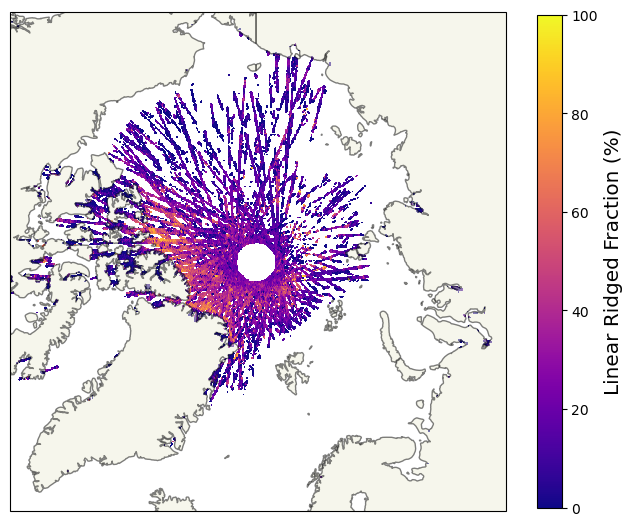

In [52]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)

m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  100*frac_grid,
                  vmin = 0,
                  vmax = 100,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb = fig.colorbar(m,shrink=0.8)
cb.set_label('Linear Ridged Fraction (%)',fontsize='x-large')

# plt.savefig('../figs/linear_ridged_frac_grid.png',dpi=500,bbox_inches='tight')

In [70]:
conc=pickle.load(open('conc.p','rb'))
conc[conc>0.1]=1
conc[conc<=0.1]=0
conc[np.isnan(conc)]=0
conc[psn_lat<66]=0

In [65]:
inds_to_fill=np.argwhere(np.isnan(frac_grid)&(conc==1))
xys = [(x[i,j],y[i,j]) for i,j in inds_to_fill]
track_tree = KDTree(list(zip(df['x'],df['y'])))



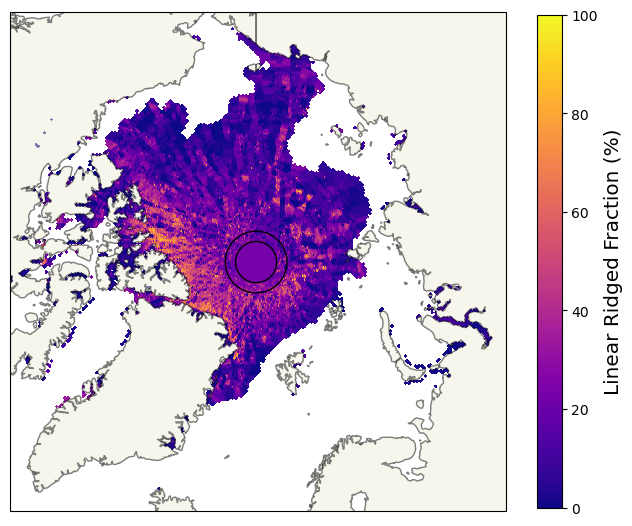

In [75]:
tree_output=track_tree.query(xys,k=10)
mean_fractions=[np.nanmean(df.iloc[ind]['frac']) for ind in tree_output[1]]

frac_grid_filled=frac_grid.copy()
for (i,j),mean_frac in zip(inds_to_fill,mean_fractions):
    frac_grid_filled[i,j] = mean_frac

frac_grid_filled[psn_lat>88]=np.nanmean(frac_grid_filled[(psn_lat>87)&(psn_lat<88)])

frac_grid_filled[conc<0.1]=np.nan

fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)

m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  100*frac_grid_filled,
                  vmin = 0,
                  vmax = 100,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

ax.gridlines(ylocs=[87,88],xlocs=[],color='k',linewidth=1,zorder=10)

cb = fig.colorbar(m,shrink=0.8)
cb.set_label('Linear Ridged Fraction (%)',fontsize='x-large')
